In [173]:
from pathlib import Path
import seaborn as sns

import itertools
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from matplotlib.pyplot import xticks
from scipy.stats import wilcoxon
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter

from CustomSpeachDataset import CustomSpeachDataset
from SpeachClassifierModel import SpeachClassifierModel

In [174]:
device = device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [175]:
MODELS_DIR = Path("checkpoints")
MODELS_DIR.mkdir(exist_ok=True)

In [176]:
dataset = CustomSpeachDataset(Path("preprocessed_dataset"), preload=True)
dataset.to(device)

Preloading dataset from disk...


In [177]:
whole_train_indices, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=dataset.y.cpu(),
    random_state=42
)

class_weights = 1.0 / dataset.label_counts
all_sample_weights = np.array([class_weights[y] for y in dataset.y.cpu()])

whole_y_train = dataset.y.cpu()[whole_train_indices]

test_dataset = torch.utils.data.Subset(dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=1024)

len(whole_train_indices), len(test_indices)

(14679, 3670)

In [178]:
def train_new_model(writer: SummaryWriter, train_ratio: float, params: dict, train_loader: DataLoader, val_loader) -> SpeachClassifierModel:
    model = SpeachClassifierModel(params["dropout_rate"])
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])

    best_val_loss = 99999999999.9

    loss_fn = nn.CrossEntropyLoss()

    train_loss_per_epoch = []
    val_loss_per_epoch = []

    for epoch in range(params["epochs"]):
        model.train()
        train_loss = 0.0
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target)
            train_loss += loss.item()

            loss.backward()
            optimizer.step()

        train_loss /= len(train_loader)
        train_loss_per_epoch.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                y_pred = model(data)
                loss = loss_fn(y_pred, target)
                val_loss += loss.item()
            val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        val_loss_per_epoch.append(val_loss)

        writer.add_scalar(f"Loss/train/train_ratio{train_ratio}", train_loss, epoch)
        writer.add_scalar(f"Loss/val/train_ratio{train_ratio}", val_loss, epoch)

    model.best_val_loss = best_val_loss
    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_epoch = val_loss_per_epoch

    return model

In [179]:
params = {
    "lr": 0.001,
    "dropout_rate": 0.15,
    "weight_decay": 0.0006,
    "epochs": 50,
}

(MODELS_DIR/"train_ratios").mkdir(exist_ok=True)

models = []
train_ratios = [0.2, 0.4, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]

for train_ratio in train_ratios:
    # train_subindex = whole_train_indices[:floor(len(whole_train_indices)*train_ratio)]
    if train_ratio < 1.0:
        train_subindex, _ = train_test_split(
            whole_train_indices,
            stratify=whole_y_train,
            train_size=train_ratio,
            random_state=42,
        )
    else:
        train_subindex = whole_train_indices

    print(f"Training ratio: {train_ratio}, subset len: {len(train_subindex)}")

    train_sample_weights = all_sample_weights[train_subindex]
    train_sampler = WeightedRandomSampler(
        weights=train_sample_weights,
        num_samples=len(train_sample_weights),
        replacement=True,
    )
    train_subset = torch.utils.data.Subset(dataset, train_subindex)
    train_loader = DataLoader(train_subset, batch_size=32, sampler=train_sampler)

    with SummaryWriter(f"runs/train_ratio") as writer:
        model = train_new_model(writer, train_ratio, params, train_loader, test_loader)
        models.append(model)

        save_path = MODELS_DIR/"train_ratios"/f"ratio_{train_ratio}.pth"
        torch.save(model.state_dict(), save_path)

        metrics = {
            "test_loss": model.best_val_loss,
        }
        writer.add_hparams({"train_ratio": train_ratio}, metrics, run_name=f"train_ratio_{train_ratio:.1f}")

models = nn.ModuleList(models)

Training ratio: 0.2, subset len: 2935
Training ratio: 0.4, subset len: 5871
Training ratio: 0.6, subset len: 8807
Training ratio: 0.7, subset len: 10275
Training ratio: 0.8, subset len: 11743
Training ratio: 0.85, subset len: 12477
Training ratio: 0.9, subset len: 13211
Training ratio: 0.95, subset len: 13945


InvalidParameterError: The 'train_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 1.0 instead.

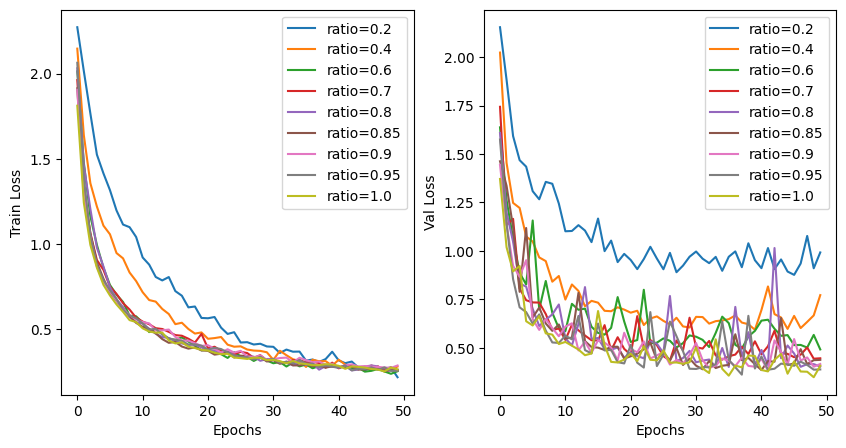

In [185]:
epochs_arr = np.arange(params["epochs"])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, model in enumerate(models):
    axs[0].plot(epochs_arr, model.train_loss_per_epoch, label=f"ratio={train_ratios[i]}")
    axs[1].plot(epochs_arr, model.val_loss_per_epoch, label=f"ratio={train_ratios[i]}")

axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Train Loss")
axs[0].legend()

axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Val Loss")
axs[1].legend()
plt.show()

Text(0, 0.5, 'best val Loss')

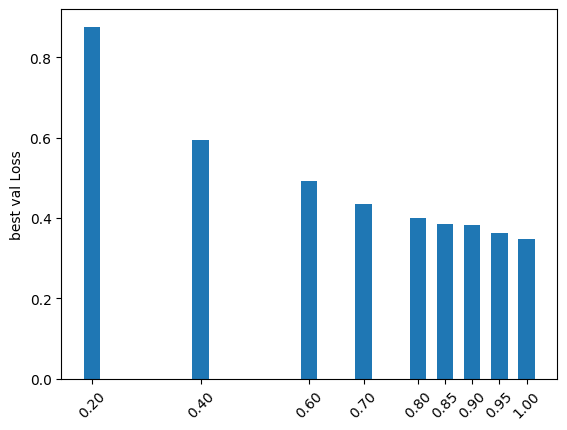

In [186]:
plt.bar(train_ratios, [model.best_val_loss for model in models], width=0.03)
plt.xticks(train_ratios, rotation=45)
plt.ylabel("best val Loss")

training_ratio=0.2
f1_score_weighted=0.7474
balanced_accuracy=0.7495


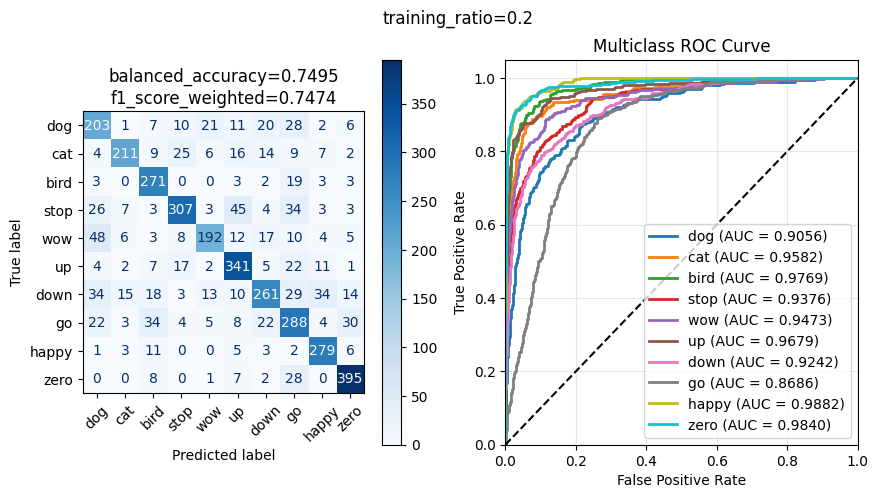




training_ratio=0.4
f1_score_weighted=0.7959
balanced_accuracy=0.8024


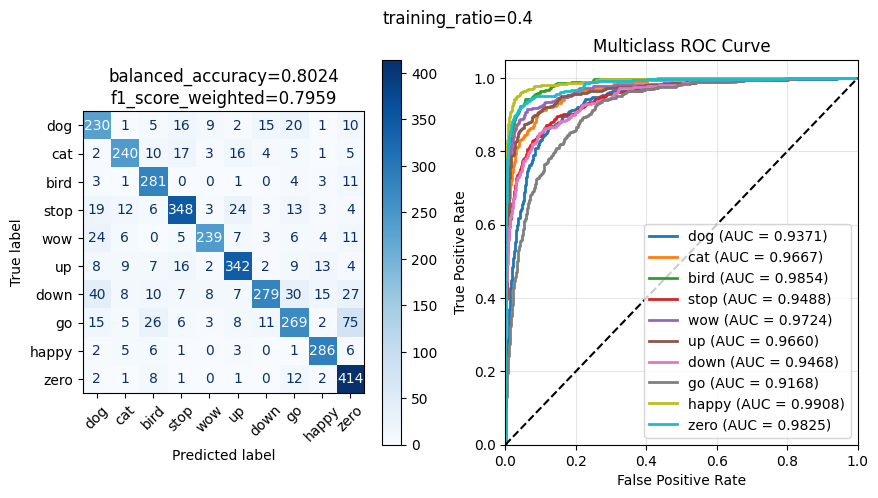




training_ratio=0.6
f1_score_weighted=0.8512
balanced_accuracy=0.8539


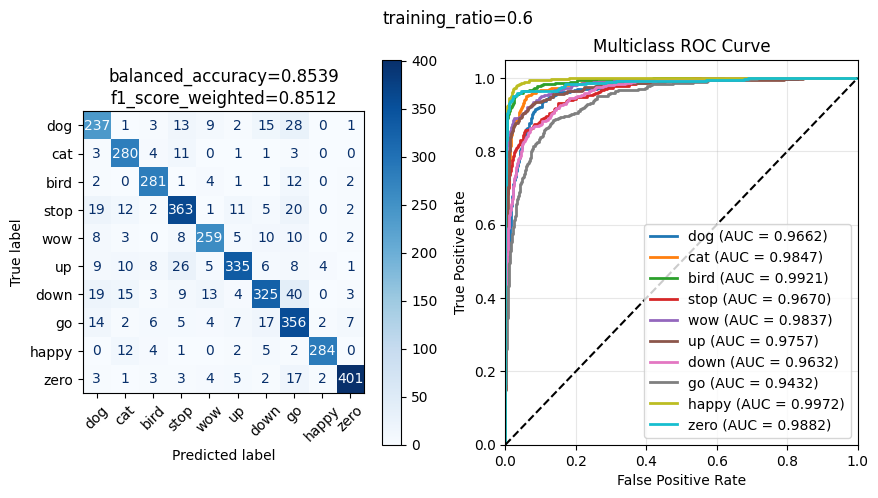




training_ratio=0.7
f1_score_weighted=0.8636
balanced_accuracy=0.8649


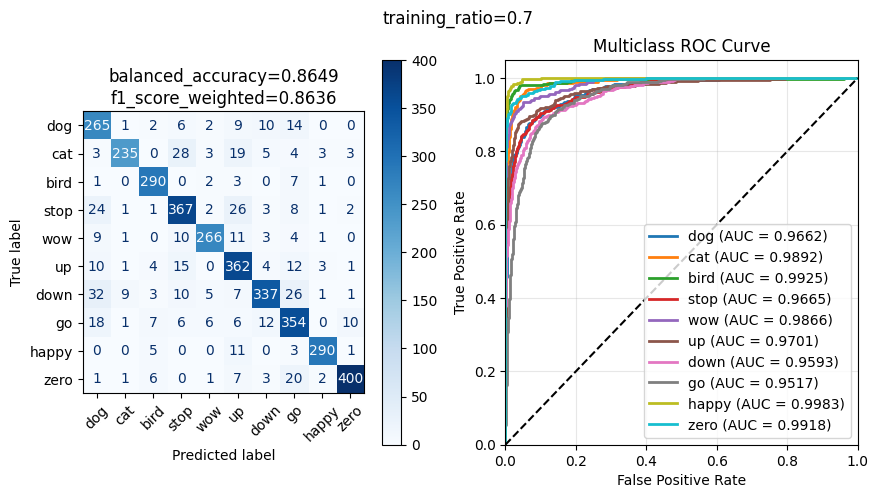




training_ratio=0.8
f1_score_weighted=0.8792
balanced_accuracy=0.8836


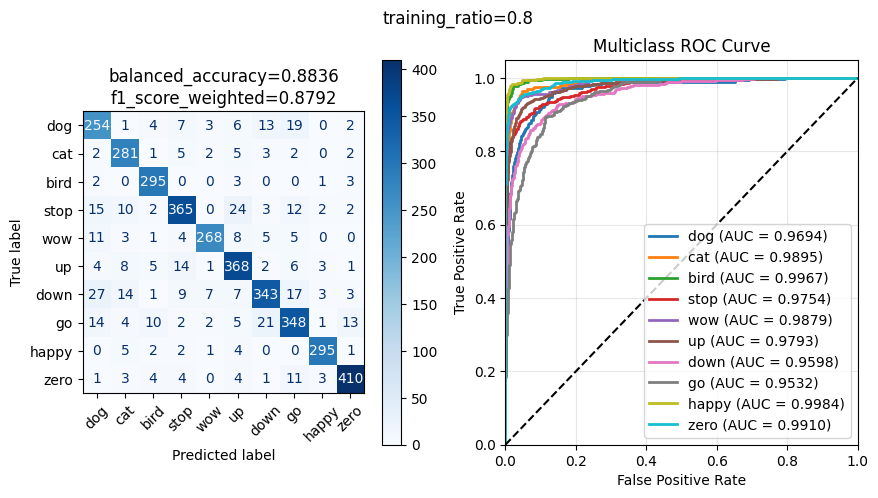




training_ratio=0.85
f1_score_weighted=0.8708
balanced_accuracy=0.8755


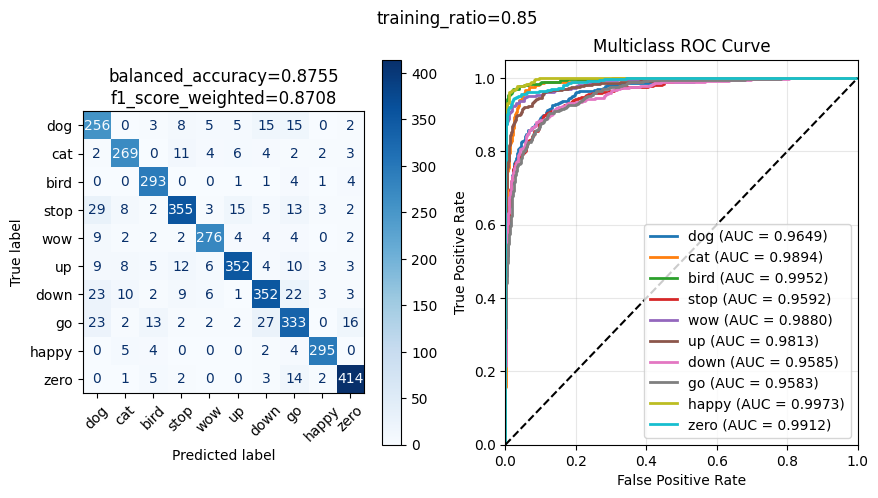




training_ratio=0.9
f1_score_weighted=0.8723
balanced_accuracy=0.8759


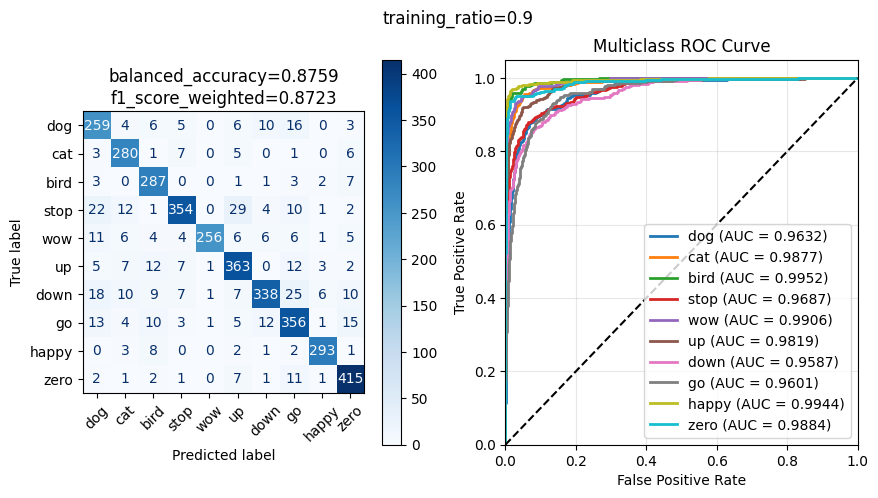




training_ratio=0.95
f1_score_weighted=0.8811
balanced_accuracy=0.8858


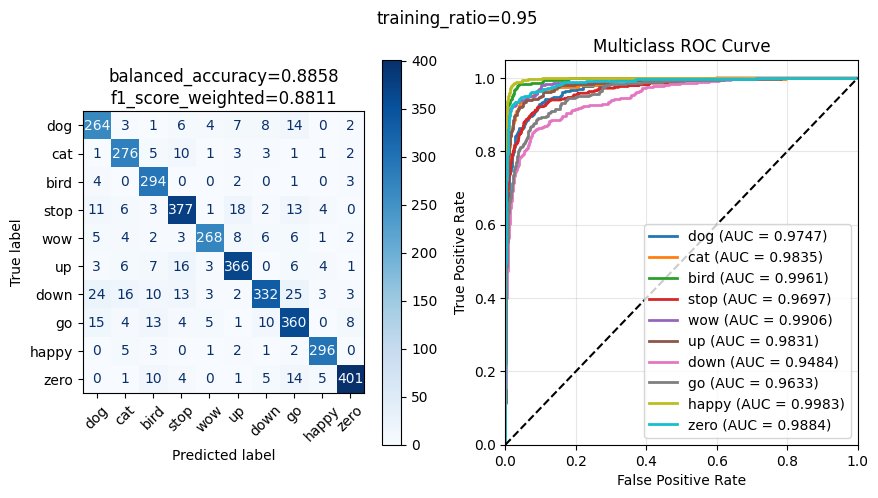




training_ratio=1.0
f1_score_weighted=0.8833
balanced_accuracy=0.8876


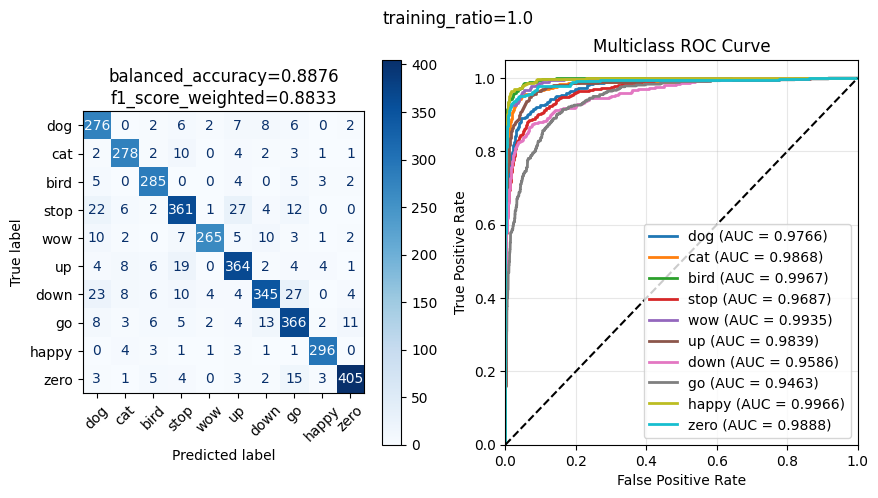

In [187]:
y_pred = np.zeros((len(models), len(test_dataset)))

for idx, model in enumerate(models):
    model.eval()

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle(f"training_ratio={train_ratios[idx]}")

    probs_batches = []
    y_test_batches = []
    with torch.no_grad():
        for X, y in test_loader:
            y_pred_step = model(X).cpu()
            probs_batches.append(y_pred_step)
            y_test_batches.append(y.cpu())

    probs = np.concatenate(probs_batches)
    y_test = np.concatenate(y_test_batches)
    y_pred[idx] = np.argmax(probs, axis=1)

    balanced_accuracy = balanced_accuracy_score(y_test, y_pred[idx])
    f1_score_weighted = f1_score(y_test, y_pred[idx], average='weighted')

    print(f"training_ratio={train_ratios[idx]}")
    print(f"{f1_score_weighted=:.4f}")
    print(f"{balanced_accuracy=:.4f}")

    classes = dataset.LABEL_NAMES

    ax = axs[0]
    cm = confusion_matrix(y_test, y_pred[idx])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
    ax.set_title(f"{balanced_accuracy=:.4f}\n{f1_score_weighted=:.4f}")

    ax = axs[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = len(dataset.LABEL_NAMES)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test == i, probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown",
              "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

    for i, color in zip(range(n_classes), colors):
        ax.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f'{dataset.LABEL_NAMES[i]} (AUC = {roc_auc[i]:.4f})'
        )

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    plt.show()

    print("\n\n")

In [188]:
names = [f"r={train_ratios[i]}" for i in range(len(train_ratios))]

f1_for_models = []
for idx in range(len(models)):
    f1_ovr = f1_score(y_test, y_pred[idx], average=None)
    f1_for_models.append(f1_ovr)

winners = []
for i in range(len(classes)):
    f1_for_this_class = [f1_scores[i] for f1_scores in f1_for_models]
    winner_idx = np.argmax([f1_for_this_class])
    winner = names[winner_idx]
    winners.append(winner)

df = pd.DataFrame({
    "label": dataset.LABEL_NAMES,
    **{names[ens_idx]: f1_ovr for ens_idx, f1_ovr in enumerate(f1_for_models)},
    "winner": winners,
})
df

,label,r=0.2,r=0.4,r=0.6,r=0.7,r=0.8,r=0.85,r=0.9,r=0.95,r=1.0,winner
0,dog,0.620795,0.703364,0.760835,0.788690,0.794992,0.775758,0.803101,0.830189,0.833837,r=1.0
1,cat,0.765880,0.812183,0.876369,0.849910,0.889241,0.884868,0.888889,0.884615,0.907015,r=1.0
2,bird,0.802963,0.847662,0.909385,0.932476,0.937997,0.925750,0.891304,0.901840,0.917874,r=0.8
3,stop,0.758962,0.816901,0.829714,0.836944,0.861865,0.849282,0.860267,0.868664,0.841492,r=0.95
4,wow,0.700730,0.835664,0.857616,0.898649,0.910017,0.909390,0.907801,0.906937,0.913793,r=1.0
5,up,0.783908,0.831106,0.853503,0.829324,0.869976,0.882206,0.861210,0.890511,0.869773,r=0.95
6,down,0.668374,0.745989,0.794621,0.834158,0.834550,0.830189,0.840796,0.832080,0.843521,r=1.0
7,go,0.647919,0.681876,0.777293,0.811927,0.828571,0.791914,0.825986,0.835267,0.849188,r=1.0
8,happy,0.849315,0.893750,0.943522,0.947712,0.954693,0.953150,0.948220,0.948718,0.954839,r=1.0
9,zero,0.871965,0.821429,0.932558,0.931315,0.933941,0.930337,0.915105,0.929316,0.932106,r=0.8


      r=0.2  r=0.4  r=0.6  r=0.7  r=0.8  r=0.85  r=0.9  r=0.95  r=1.0
won=      0      0      0      0      2       0      0       2      6


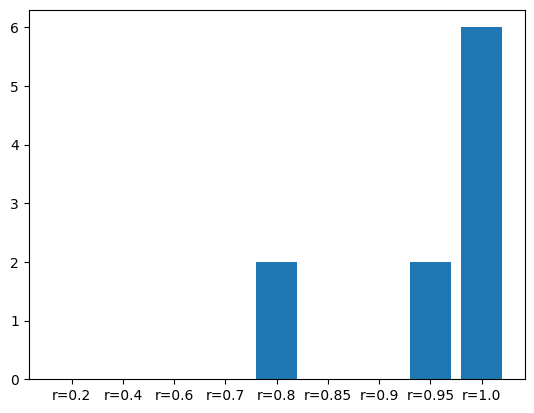

In [189]:
winner_n_times_row = pd.DataFrame({
    **{name: np.sum(df["winner"] == name) for name in names},
}, index=["won="])
print(winner_n_times_row)
plt.bar(winner_n_times_row.columns, winner_n_times_row.iloc[0])
plt.show()

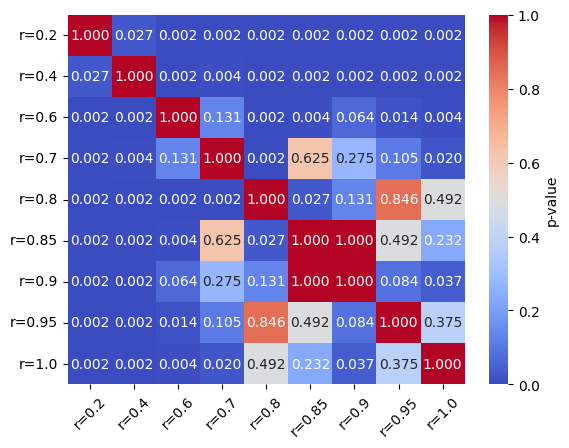

In [190]:
p_matrix = np.ones((len(f1_for_models), len(f1_for_models)))

for i, j, in itertools.combinations(range(len(f1_for_models)), 2):
    _, p_val = wilcoxon(f1_for_models[i], f1_for_models[j])
    p_matrix[i, j] = p_val
    p_matrix[j, i] = p_val
    # print(f"{names[i]} vs {names[j]} p={p_val:.4f}")

df_p = pd.DataFrame(p_matrix, index=names, columns=names)

sns.heatmap(
    df_p,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    fmt=".3f",
    cbar_kws={'label': 'p-value'},
)
plt.xticks(rotation=45)
plt.show()